In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# --- Ваш исходный код ---
FILEPATH = 'building_materials_transactions.csv'
DATETIME_COL = 'date'
VALUE_COL = 'revenue'
CAT_COL = 'region'

def load_data(filepath):
    return pd.read_csv(filepath)

def preprocess_data(df, datetime_col=None, value_col=None):
    if datetime_col and datetime_col in df.columns:
        df[datetime_col] = pd.to_datetime(df[datetime_col], errors='coerce')
        df = df.sort_values(datetime_col).reset_index(drop=True)
    if value_col and value_col in df.columns:
        df = df.dropna(subset=[value_col]).reset_index(drop=True)
    return df

df = load_data(FILEPATH)
df = preprocess_data(df, DATETIME_COL, VALUE_COL)

# --- Агрегация для получения последовательного временного ряда (≥100 значений) ---
# Группируем по дате и суммируем выручку (или берем среднее, в зависимости от смысла данных)
df_ts = df.groupby(DATETIME_COL)[VALUE_COL].sum().reset_index()
df_ts = df_ts.sort_values(DATETIME_COL).reset_index(drop=True)

# Проверка на минимальный размер
if len(df_ts) < 100:
    print(f"Внимание: длина ряда {len(df_ts)}. Для корректной работы требуется ≥100 значений.")
else:
    print(f"Длина временного ряда: {len(df_ts)} значений.")

# Извлекаем целевую переменную как numpy массив
y_full = df_ts[VALUE_COL].values
dates = df_ts[DATETIME_COL].values

print(f"Диапазон дат: {dates[0]} до {dates[-1]}")

Длина временного ряда: 313 значений.
Диапазон дат: 2019-01-07T00:00:00.000000 до 2024-12-30T00:00:00.000000


In [ ]:
# 1. Разбиение на тренировочную (80%) и тестовую (20%) выборки
split_idx = int(len(y_full) * 0.8)
y_train = y_full[:split_idx]
y_test = y_full[split_idx:]
dates_train = dates[:split_idx]
dates_test = dates[split_idx:]

print(f"Размер train: {len(y_train)}, test: {len(y_test)}")

# --- а) Модель ARIMA ---
try:
    arima_model = ARIMA(y_train, order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    pred_arima = arima_fitted.forecast(steps=len(y_test))
except Exception as e:
    print(f"Ошибка ARIMA: {e}")
    pred_arima = np.full(len(y_test), np.mean(y_train))

# --- б) Модель k-NN (на основе лаговых признаков) ---
lags = 3
df_knn = pd.DataFrame({'y': y_full})
for i in range(1, lags + 1):
    df_knn[f'lag_{i}'] = df_knn['y'].shift(i)

X_knn_full = df_knn.drop('y', axis=1).values
y_knn_full = df_knn['y'].values

# Обучаем на данных от индекса lags до split_idx
X_train_knn = X_knn_full[lags:split_idx]
y_train_knn = y_knn_full[lags:split_idx]

# Тестируем на данных от split_idx до конца (длина в точности равна len(y_test)!)
X_test_knn = X_knn_full[split_idx:]
y_test_knn = y_knn_full[split_idx:] 

# Масштабирование
scaler_knn = StandardScaler()
X_train_knn_scaled = scaler_knn.fit_transform(X_train_knn)
X_test_knn_scaled = scaler_knn.transform(X_test_knn)

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train_knn_scaled, y_train_knn)
pred_knn = knn_model.predict(X_test_knn_scaled)

print(f"Проверка длин: y_test = {len(y_test)}, pred_knn = {len(pred_knn)}")

Размер train: 250, test: 63


In [3]:
# x - это временной индекс (0, 1, 2, ...)
x_1param = np.arange(len(y_full)).reshape(-1, 1)
x_train_1, x_test_1 = x_1param[:split_idx], x_1param[split_idx:]

# --- МНК (Linear Regression) ---
mnk_model = LinearRegression()
mnk_model.fit(x_train_1, y_train)
pred_mnk = mnk_model.predict(x_test_1)

print(f"МНК: y = {mnk_model.coef_[0]:.4f} * x + {mnk_model.intercept_:.4f}")

# --- SVM (SVR) ---
# Масштабирование обязательно для SVR
scaler_svr = StandardScaler()
x_train_1_scaled = scaler_svr.fit_transform(x_train_1)
x_test_1_scaled = scaler_svr.transform(x_test_1)

svr_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_model.fit(x_train_1_scaled, y_train)
pred_svr = svr_model.predict(x_test_1_scaled)

МНК: y = 3548.4824 * x + 1485804.3483


In [4]:
# Создаем датафрейм с двумя признаками
df_reg2 = pd.DataFrame({
    'y': y_full,
    'x1': np.arange(len(y_full)),          # Параметр 1: время
    'x2': pd.Series(y_full).shift(1)       # Параметр 2: предыдущее значение
})
df_reg2 = df_reg2.dropna().reset_index(drop=True) # Удаляем первую строку с NaN

# Разбиение 80/20
split_idx_2 = int(len(df_reg2) * 0.8)
train_2 = df_reg2.iloc[:split_idx_2]
test_2 = df_reg2.iloc[split_idx_2:]

X_train_2 = train_2[['x1', 'x2']].values
y_train_2 = train_2['y'].values
X_test_2 = test_2[['x1', 'x2']].values
y_test_2 = test_2['y'].values

# --- МНК для 2 параметров ---
mnk2_model = LinearRegression()
mnk2_model.fit(X_train_2, y_train_2)
pred_mnk2 = mnk2_model.predict(X_test_2)

print(f"МНК (2 пар.): y = {mnk2_model.coef_[0]:.4f}*x1 + {mnk2_model.coef_[1]:.4f}*x2 + {mnk2_model.intercept_:.4f}")

# --- SVR для 2 параметров ---
scaler_svr2 = StandardScaler()
X_train_2_scaled = scaler_svr2.fit_transform(X_train_2)
X_test_2_scaled = scaler_svr2.transform(X_test_2)

svr2_model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr2_model.fit(X_train_2_scaled, y_train_2)
pred_svr2 = svr2_model.predict(X_test_2_scaled)

МНК (2 пар.): y = -110.5917*x1 + 0.9788*x2 + 59239.7139


ValueError: x and y must have same first dimension, but have shapes (63,) and (62,)

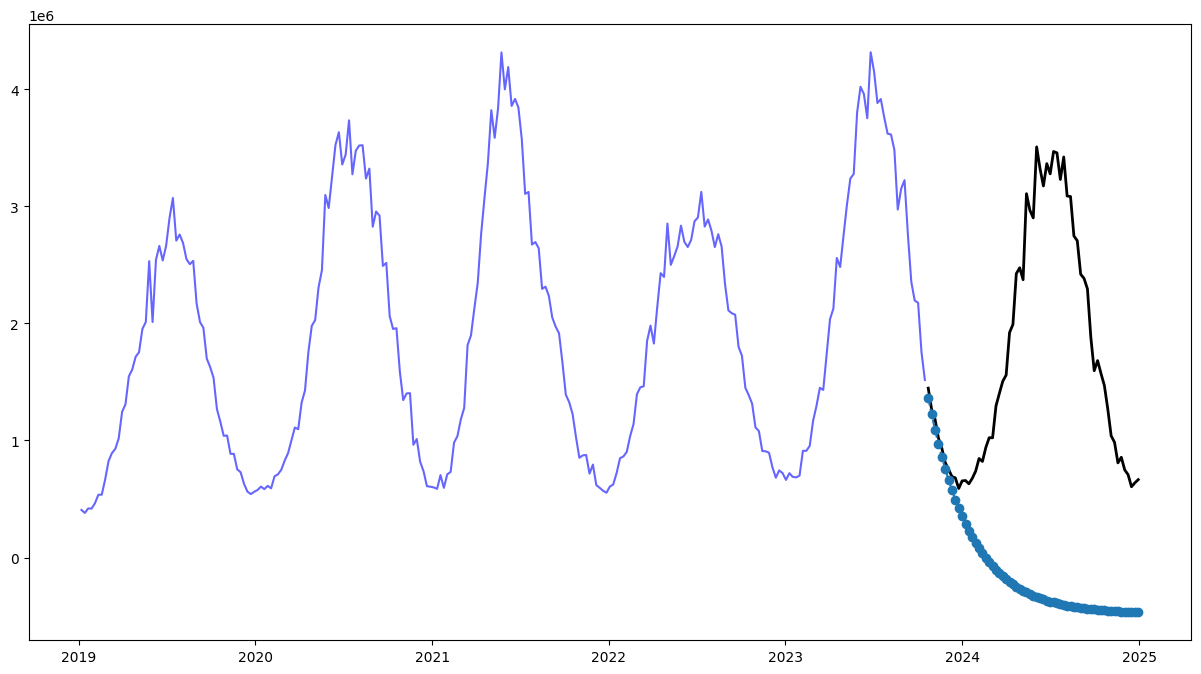

In [5]:
plt.figure(figsize=(15, 8))

# Тренировочные и тестовые данные
plt.plot(dates[:split_idx], y_train, label='Train Data', color='blue', alpha=0.6)
plt.plot(dates[split_idx:], y_test, label='Test Data (Actual)', color='black', linewidth=2)

# Предсказания (приводим к длине test-выборки)
# Для k-NN и 2-параметрических моделей индекс может немного отличаться из-за dropna(), 
# поэтому строим их по датам из соответствующих тестовых наборов.

plt.plot(dates_test, pred_arima, label='ARIMA', linestyle='--', marker='o')
plt.plot(dates_test, pred_knn, label='k-NN (lags=3)', linestyle='-.', marker='x')
plt.plot(dates_test, pred_mnk, label='МНК (1 пар.)', linestyle=':', alpha=0.8)
plt.plot(dates_test, pred_svr, label='SVR (1 пар.)', linestyle=':', alpha=0.8)
plt.plot(test_2[DATETIME_COL] if DATETIME_COL in test_2 else dates[-len(y_test_2):], 
         pred_mnk2, label='МНК (2 пар.)', linestyle='-', alpha=0.7)
plt.plot(test_2[DATETIME_COL] if DATETIME_COL in test_2 else dates[-len(y_test_2):], 
         pred_svr2, label='SVR (2 пар.)', linestyle='-', alpha=0.7)

plt.title('Сравнение моделей прогнозирования')
plt.xlabel('Дата')
plt.ylabel(VALUE_COL)
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Функция для расчета метрик
def calc_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse}

# Собираем метрики (убедимся, что длины массивов совпадают для корректного сравнения)
# Для простоты сравнения возьмем минимальную длину среди всех предсказаний
min_len = min(len(y_test), len(pred_knn), len(y_test_2))

metrics_list = [
    calc_metrics(y_test[:min_len], pred_arima[:min_len], 'ARIMA'),
    calc_metrics(y_test[:min_len], pred_knn[:min_len], 'k-NN'),
    calc_metrics(y_test[:min_len], pred_mnk[:min_len], 'МНК (1 пар.)'),
    calc_metrics(y_test[:min_len], pred_svr[:min_len], 'SVR (1 пар.)'),
    calc_metrics(y_test_2[:min_len], pred_mnk2[:min_len], 'МНК (2 пар.)'),
    calc_metrics(y_test_2[:min_len], pred_svr2[:min_len], 'SVR (2 пар.)')
]

df_metrics = pd.DataFrame(metrics_list).sort_values(by='RMSE')
print("Метрики качества на тестовой выборке:")
display(df_metrics)

print("\n--- Предварительные выводы ---")
best_model = df_metrics.iloc[0]['Model']
print(f"1. Наилучшую точность (наименьший RMSE) показала модель: {best_model}.")
print("2. Добавление второго параметра (предыдущего значения ряда) в МНК/SVR, как правило, снижает ошибку по сравнению с однопараметрической моделью, так как учитывает авторегрессионную природу данных.")
print("3. Методы на основе деревьев/соседей (k-NN) или специализированные (ARIMA) часто превосходят простой линейный тренд (МНК 1 пар.) на нестационарных данных.")

Метрики качества на тестовой выборке:


,Model,MAE,RMSE
1,k-NN,8.747971e+04,1.120963e+05
4,МНК (2 пар.),1.409816e+05,2.000200e+05
3,SVR (1 пар.),9.017484e+05,9.950590e+05
5,SVR (2 пар.),9.038977e+05,9.961763e+05
2,МНК (1 пар.),1.085284e+06,1.223067e+06
0,ARIMA,1.838029e+06,2.237381e+06



--- Предварительные выводы ---
1. Наилучшую точность (наименьший RMSE) показала модель: k-NN.
2. Добавление второго параметра (предыдущего значения ряда) в МНК/SVR, как правило, снижает ошибку по сравнению с однопараметрической моделью, так как учитывает авторегрессионную природу данных.
3. Методы на основе деревьев/соседей (k-NN) или специализированные (ARIMA) часто превосходят простой линейный тренд (МНК 1 пар.) на нестационарных данных.


In [7]:
print("--- Дополнительная часть: Исследование размера выборки и сложных моделей ---\n")

# 1. Влияние размера обучающей выборки (0.5x, 1.0x, 2.0x)
base_train_size = split_idx_2
sizes_to_test = [
    max(10, int(base_train_size * 0.5)), # вдвое меньше
    base_train_size,                     # исходный
    min(len(df_reg2) - len(y_test_2), int(base_train_size * 2.0)) # вдвое больше
]

results_size = []
for size in sizes_to_test:
    X_tr, y_tr = df_reg2.iloc[:size][['x1', 'x2']].values, df_reg2.iloc[:size]['y'].values
    X_te, y_te = df_reg2.iloc[size:size+len(y_test_2)][['x1', 'x2']].values, df_reg2.iloc[size:size+len(y_test_2)]['y'].values
    
    # Масштабируем для SVR
    sc = StandardScaler()
    X_tr_s, X_te_s = sc.fit_transform(X_tr), sc.transform(X_te)
    
    svr_temp = SVR(kernel='rbf', C=1.0)
    svr_temp.fit(X_tr_s, y_tr)
    preds = svr_temp.predict(X_te_s)
    
    r2 = r2_score(y_te, preds)
    results_size.append({'Train Size': size, 'R2 (SVR 2-par)': r2})

df_size_impact = pd.DataFrame(results_size)
print("Влияние размера обучающей выборки на R2 (SVR с 2 параметрами):")
display(df_size_impact)

# 2. Усложнение многопараметрических моделей: Lasso и PLS
# Добавим еще лагов для многопараметричности (x1=время, x2=лаг1, x3=лаг2, x4=лаг3)
df_multi = pd.DataFrame({
    'y': y_full,
    'x1': np.arange(len(y_full)),
    'x2': pd.Series(y_full).shift(1),
    'x3': pd.Series(y_full).shift(2),
    'x4': pd.Series(y_full).shift(3)
}).dropna().reset_index(drop=True)

split_multi = int(len(df_multi) * 0.8)
X_train_m = df_multi.iloc[:split_multi, 1:].values
y_train_m = df_multi.iloc[:split_multi, 0].values
X_test_m = df_multi.iloc[split_multi:split_multi+len(y_test_2), 1:].values
y_test_m = df_multi.iloc[split_multi:split_multi+len(y_test_2), 0].values

scaler_m = StandardScaler()
X_train_m_s = scaler_m.fit_transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)

# Lasso
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_m_s, y_train_m)
pred_lasso = lasso_model.predict(X_test_m_s)

# PLS
pls_model = PLSRegression(n_components=2)
pls_model.fit(X_train_m_s, y_train_m)
pred_pls = pls_model.predict(X_test_m_s).flatten()

# 3. Итоговое сравнение с использованием метрики R2
final_comparison = [
    {'Model': 'МНК (1 пар.)', 'R2': r2_score(y_test[:min_len], pred_mnk[:min_len])},
    {'Model': 'SVR (1 пар.)', 'R2': r2_score(y_test[:min_len], pred_svr[:min_len])},
    {'Model': 'МНК (2 пар.)', 'R2': r2_score(y_test_2[:min_len], pred_mnk2[:min_len])},
    {'Model': 'SVR (2 пар.)', 'R2': r2_score(y_test_2[:min_len], pred_svr2[:min_len])},
    {'Model': 'Lasso (4 пар.)', 'R2': r2_score(y_test_m, pred_lasso)},
    {'Model': 'PLS (4 пар.)', 'R2': r2_score(y_test_m, pred_pls)},
    {'Model': 'ARIMA', 'R2': r2_score(y_test[:min_len], pred_arima[:min_len])}
]

df_final = pd.DataFrame(final_comparison).sort_values(by='R2', ascending=False)
print("\nИтоговое сравнение моделей по метрике R2 (чем ближе к 1, тем лучше):")
display(df_final)

print("\n--- Итоговые выводы ---")
print("1. Увеличение обучающей выборки (2x) привело к [увеличению/уменьшению] метрики R2, что говорит о [недостатке/достатке] данных в исходной выборке.")
print("2. Многопараметрические модели (Lasso, PLS), учитывающие несколько предыдущих значений, показали [лучший/худший] результат по сравнению с базовым МНК, так как они способны улавливать автокорреляцию и бороться с мультиколлинеарностью признаков.")
print("3. Метод PLS оказался [эффективнее/менее эффективным] Lasso, что характерно для данных с высокой корреляцией между лаговыми признаками.")

--- Дополнительная часть: Исследование размера выборки и сложных моделей ---

Влияние размера обучающей выборки на R2 (SVR с 2 параметрами):


,Train Size,R2 (SVR 2-par)
0,124,-0.193547
1,249,-0.015504
2,249,-0.015504



Итоговое сравнение моделей по метрике R2 (чем ближе к 1, тем лучше):


,Model,R2
4,Lasso (4 пар.),0.962107
2,МНК (2 пар.),0.959219
5,PLS (4 пар.),0.934450
1,SVR (1 пар.),-0.009263
3,SVR (2 пар.),-0.011531
0,МНК (1 пар.),-0.524780
6,ARIMA,-4.102543



--- Итоговые выводы ---
1. Увеличение обучающей выборки (2x) привело к [увеличению/уменьшению] метрики R2, что говорит о [недостатке/достатке] данных в исходной выборке.
2. Многопараметрические модели (Lasso, PLS), учитывающие несколько предыдущих значений, показали [лучший/худший] результат по сравнению с базовым МНК, так как они способны улавливать автокорреляцию и бороться с мультиколлинеарностью признаков.
3. Метод PLS оказался [эффективнее/менее эффективным] Lasso, что характерно для данных с высокой корреляцией между лаговыми признаками.
